# Z24: prepare data with Jupyter

Install dependencies with `python -m pip install -r requirements.txt`, then run this notebook from the `AI` folder. The reader is in `z24_prepare.py`.


In [2]:
from pathlib import Path
import sys, json
import numpy as np
ROOT = Path.cwd()
if not (ROOT / 'z24_prepare.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'z24_prepare.py').exists(), 'Open notebook from AI or notebooks'
sys.path.insert(0, str(ROOT))
import importlib
import z24_prepare
# Reload after edits, even when this kernel imported an older version.
importlib.invalidate_caches()
z24_prepare = importlib.reload(z24_prepare)
from z24_prepare import inventory, prepare, read_windows_csv
ARCHIVE = ROOT / 'raw_data' / 'sources-Z24-004.zip'


## 1. Scope

This notebook processes numeric-suffix `.aaa` channels in the EMS group. The outer ZIP is truncated, so incomplete packages are skipped and raw data is never modified.


In [3]:
members = inventory(ARCHIVE)
for member in members:
    print(member['name'], 'complete=', member['complete'], 'bytes=', member['packed'])


C11-Appendices.pdf complete= True bytes= 78439877
pdt_01-08.zip complete= True bytes= 2026710329
pdt_09_17.zip complete= True bytes= 2101731711
readme.txt complete= True bytes= 208
Z24ems1.zip complete= True bytes= 2071867864
Z24ems2.zip complete= True bytes= 2064717779
Z24ems3.zip complete= False bytes= 2286562254


## 2. Configuration

`MAX_SESSIONS = 20` is a smoke test. Set it to `None` for all complete sessions. `WINDOW_SECONDS = 10` creates 1,000 samples per example at 100 Hz.


In [4]:
from datetime import datetime
MAX_SESSIONS = None
WINDOW_SECONDS = 10
run_name = 'ems_csv_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
OUTPUT = ROOT / 'processed' / run_name
suffix = 2
while OUTPUT.exists():
    OUTPUT = ROOT / 'processed' / f'{run_name}_{suffix}'
    suffix += 1
report = prepare(ARCHIVE, OUTPUT, max_sessions=MAX_SESSIONS,
                 window_seconds=WINDOW_SECONDS, seed=42)
print('Output:', OUTPUT)
print(json.dumps({k: v for k, v in report.items() if k not in ('inventory', 'issues')}, indent=2))
print('Issues:', len(report['issues']))
print(json.dumps(report['issues'][:10], indent=2))


KeyboardInterrupt: 

## 3. Validation and normalization

The parser validates sample count, time step, and finite values; removes constant windows and incomplete tails; then computes train-only per-channel statistics. Sessions are split approximately 70/15/15, with all windows from one session kept together.


In [ ]:
manifest = json.loads((OUTPUT / 'manifest.json').read_text())
assert manifest, 'No valid data; see report.json'
assert all(r['normalized'] for r in manifest), 'Missing train statistics; see report'
groups = {s: {r['session'] for r in manifest if r['split'] == s} for s in ('train', 'val', 'test')}
assert groups['train'].isdisjoint(groups['val'])
assert groups['train'].isdisjoint(groups['test'])
assert groups['val'].isdisjoint(groups['test'])
for split, sessions in groups.items():
    print(split, len(sessions), 'sessions')
    assert sessions, f'Empty split {split}; increase session count'
for r in manifest:
    a, starts = read_windows_csv(OUTPUT / r['shard'])
    assert a.shape == (r['windows'], int(WINDOW_SECONDS * r['fs']), 1)
    assert a.dtype == np.float32 and np.isfinite(a).all()
print('Header mismatches:', sum(r['header_name_mismatch'] for r in manifest))
print('Shape, finite values, session isolation: OK')


## 4. Output

The output contains CSV shards in `train/`, `val/`, and `test/`, plus `manifest.json`, `normalization.json`, and `report.json`. Each CSV row is one 10-second window.


In [ ]:
CHANNEL = sorted({r['channel'] for r in manifest})[0]
def batches(split, channel=CHANNEL, batch_size=64):
    for row in manifest:
        if row['split'] != split or row['channel'] != channel:
            continue
        x, _ = read_windows_csv(OUTPUT / row['shard'])
        for start in range(0, len(x), batch_size):
            yield x[start:start + batch_size]
x = next(batches('train'))
print('Channel:', CHANNEL, 'batch shape:', x.shape)
print('Range:', float(x.min()), float(x.max()))


## 5. Limits before final training

No verified `y` labels are available yet, so classification accuracy cannot be measured. Confirm labels, sensor units, segment boundaries, and the ZIP contents before final training.


## Reviewing CSV

Open CSV files directly in VS Code. Each row has 1,001 columns; the preview cell shows the first ten samples of two windows. Values are normalized and no longer in the original g unit. `read_windows_csv` converts the table into a NumPy array for the model.


In [ ]:
import csv
preview_file = OUTPUT / manifest[0]['shard']
print(preview_file)
with preview_file.open(encoding='utf-8', newline='') as f:
    reader = csv.reader(f)
    print(next(reader)[:11])
    for _, row in zip(range(2), reader):
        print(row[:11])


## Plot signals from CSV

Run these cells to inspect an existing CSV dataset without running `prepare` again. Choose a dataset, session, and channel. The plots show normalized signal values over the relative time within each 10-second window.


In [ ]:
from pathlib import Path
import sys, json, importlib
ROOT = Path.cwd()
if not (ROOT / 'z24_prepare.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'z24_prepare.py').exists(), 'Run from AI or notebooks'
sys.path.insert(0, str(ROOT))
# Use this notebook kernel's Python, not a separate project package folder.
# Install dependencies before opening this notebook: python -m pip install -r requirements.txt
import numpy as np
import matplotlib.pyplot as plt
import z24_prepare
importlib.reload(z24_prepare)
from z24_prepare import read_windows_csv

DATA_DIR = None  # Example: ROOT / 'processed' / 'ems_csv_2026-09-12_16-44-58'
if DATA_DIR is None:
    candidates = sorted((ROOT / 'processed').glob('*/manifest.json'),
                        key=lambda p: p.stat().st_mtime, reverse=True)
    for candidate in candidates:
        chart_manifest = json.loads(candidate.read_text(encoding='utf-8'))
        if any(r['shard'].endswith('.csv') and (candidate.parent / r['shard']).exists()
               for r in chart_manifest):
            DATA_DIR = candidate.parent
            break
    else:
        raise FileNotFoundError('No processed CSV dataset; run prepare first')
DATA_DIR = Path(DATA_DIR)
chart_manifest = json.loads((DATA_DIR / 'manifest.json').read_text(encoding='utf-8'))
chart_rows = [r for r in chart_manifest if r['shard'].endswith('.csv') and r.get('normalized')]
assert chart_rows, 'No normalized CSV records'
print('Dataset:', DATA_DIR)
for row in chart_rows[:16]:
    print(row['session'], 'channel', row['channel'], row['split'], row['windows'], 'windows')


In [ ]:
SESSION = chart_rows[0]['session']  # Change to a session shown above
CHANNEL = chart_rows[0]['channel']  # Keep leading zero, e.g. '03'
WINDOW_INDEX = 0                   # 0 = first retained window

selected = next((r for r in chart_rows if r['session'] == SESSION and r['channel'] == CHANNEL), None)
assert selected is not None, 'Session/channel not found in this dataset'
chart_x, chart_starts = read_windows_csv(DATA_DIR / selected['shard'])
assert 0 <= WINDOW_INDEX < len(chart_x), f'Choose window 0..{len(chart_x)-1}'
fs = float(selected['fs'])
time_seconds = np.arange(chart_x.shape[1]) / fs
signal = chart_x[WINDOW_INDEX, :, 0]
print('CSV:', selected['shard'])
print('Shape:', chart_x.shape, 'fs:', fs, 'Hz')
print('Start sample:', chart_starts[WINDOW_INDEX])
print('First 10 signal values:', signal[:10])


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
ax.plot(time_seconds, signal, linewidth=0.8, color='tab:blue')
ax.set(title=f'{SESSION} | channel {CHANNEL} | window {WINDOW_INDEX} | {selected["split"]}',
       xlabel='Time within window (seconds)', ylabel='Standardized signal (unitless)')
ax.grid(alpha=0.25)
plt.show()


### Compare windows and value distribution

The next cell plots three windows on a shared scale and a histogram of their values.


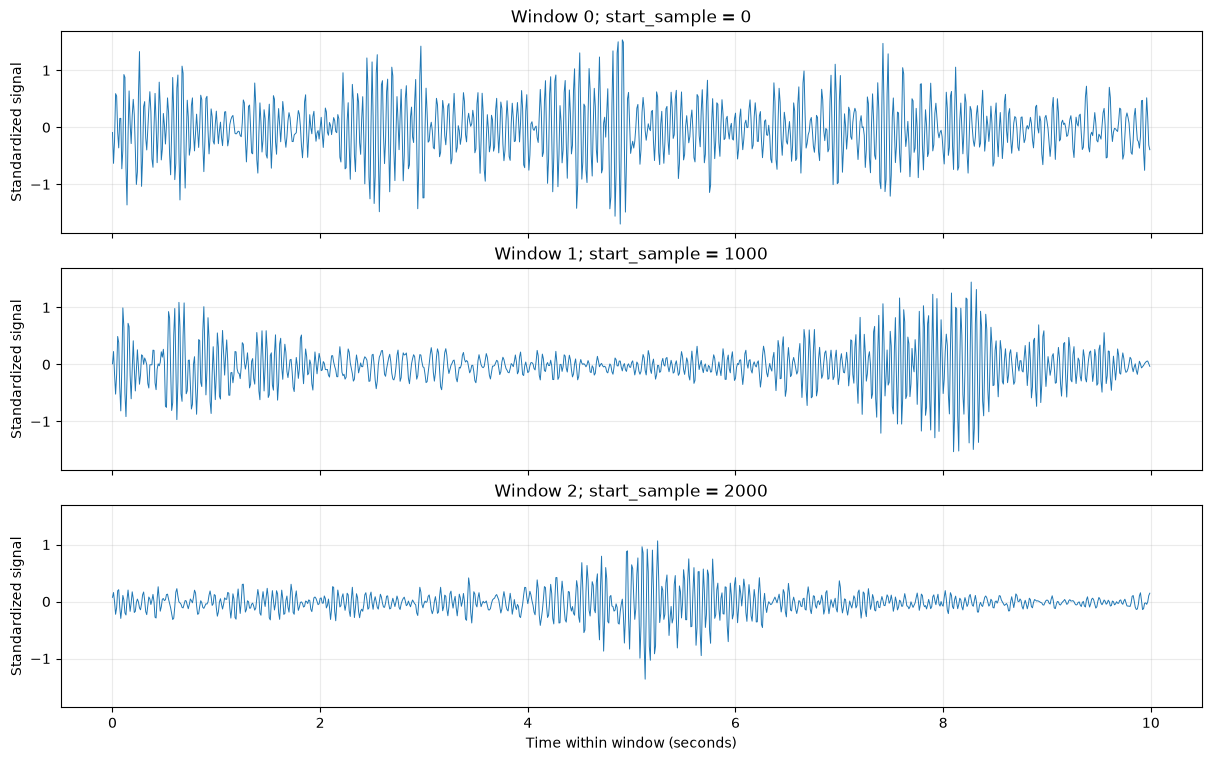

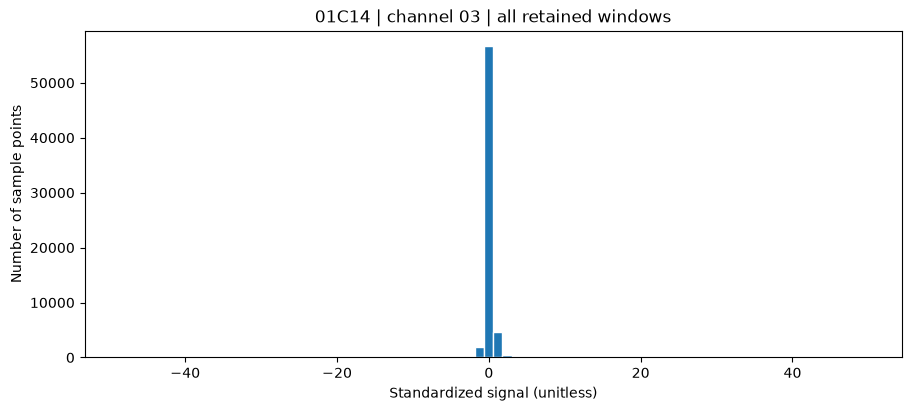

In [ ]:
indices = list(range(WINDOW_INDEX, min(WINDOW_INDEX + 3, len(chart_x))))
fig, axes = plt.subplots(len(indices), 1, figsize=(12, 2.5 * len(indices)),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
for ax, index in zip(axes[:, 0], indices):
    ax.plot(time_seconds, chart_x[index, :, 0], linewidth=0.7)
    ax.set_title(f'Window {index}; start_sample = {chart_starts[index]}')
    ax.set_ylabel('Standardized signal')
    ax.grid(alpha=0.25)
axes[-1, 0].set_xlabel('Time within window (seconds)')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
ax.hist(chart_x.ravel(), bins=80, color='tab:blue', edgecolor='white')
ax.set(title=f'{SESSION} | channel {CHANNEL} | all retained windows',
       xlabel='Standardized signal (unitless)', ylabel='Number of sample points')
plt.show()
